# What "alpha" means, and which of its meanings this repository measures

## `pairs_trading_14_alpha_concepts_day_lake.ipynb`

"Alpha signal", "alpha factor", "finding alpha" — the word is used for at least four different objects,
and only two of them have a definition you can write down. This notebook separates them, shows where
each one appears in this repository, and measures every one of them on the day lake so that the
distinctions are numbers rather than vocabulary.

The running example is notebook 11's pairs book: the top-20 BH-FDR dual-gate cointegrated pairs at each
of 39 semi-annual formations, static OLS hedge, robust $z$-score, entry at $|z|\ge2$, exit at
$|z|\le0.5$, stop at $|z|\ge4$, \$10k a pair, 5 bps a leg-side plus 50 bp/year borrow. 287 pair-folds,
723 trades, 2006–2025, realised Sharpe **0.402** over the 3,677 sessions it held an allocation and
**0.330** over all 5,438 in the lake. Both figures are used below and neither is "the" Sharpe — §3
explains why carrying two of them is the honest choice rather than an oversight.

Against it we run a deliberate foil: an equal-weight **long-only** book on the very same tickers. It has
the *higher* Sharpe on either sample. Almost everything in this notebook follows from why that
comparison is not embarrassing.

**What this notebook is not.** It is not a strategy. Nothing here is tuned, selected or held out; every
number is a measurement on results notebooks 09–12 already produced. Where a concept is already
demonstrated elsewhere in the repository — information coefficients in notebook 12, multiple-testing
control in notebooks 03 and 08, the leveraged-ETF concentration in notebook 11 — this notebook points
there rather than repeating the work.

**Caching.** The pairs book, the signal panel and the placebo are cached under `notebooks/cache/`
(`alpha_*.parquet`); a cold run is roughly six minutes.

## 0. Setup

In [1]:
from pathlib import Path
import os, sys, warnings

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))
warnings.filterwarnings("ignore")
for _v in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS", "OMP_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from joblib import Parallel, delayed

import pairs
from pairs import (load_daily_bars, generate_pair_signals, evaluate_pair_signals,
                   estimate_halflife, zscore_from_spread,
                   CostSpec, measure_ticker_window_costs, pair_fold_costs)

LAKE        = Path(os.environ.get("DAY_LAKE", Path.home() / "local/parquet_lake/day_adj"))
MARKET_ROOT = LAKE / "all_adjusted"
# section 9 is the one place this notebook leaves the day lake: costs are measured on minute bars
MINUTE_ROOT = Path(os.environ.get("MINUTE_LAKE",
                                  Path.home() / "local/parquet_lake/minute_adj")) / "all_adjusted"
CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)

START, END = "2004-01-01", "2025-08-13"
FORM_YEARS, MAX_PAIRS, CAP, COST_BPS, BORROW_BPS = 2, 20, 10_000, 5.0, 50
Z_ENTRY, Z_EXIT, Z_STOP = 2.0, 0.5, 4.0
ANN = 252
# section 9 only. HOLDOUT_FROM matches notebook 11's split, so "out of sample" means the same thing
# in both; N_SCREEN_TESTS is notebook 10's screen size, quantified in section 8.
HOLDOUT_FROM, N_SCREEN_TESTS = pd.Timestamp("2023-01-01"), 1_738_998
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 100})
print("pairs", pairs.__version__)

pairs 0.1.0


## 1. Four different things are called alpha

The confusion is real and it is not the reader's fault. These four objects share a name:

### 1.1 Jensen's alpha — the intercept of a factor regression

Jensen (1968). Given a set of $K$ factor returns $f_{k,t}$, regress a return stream on them:

$$
r_t - r_{f,t} \;=\; \alpha \;+\; \sum_{k=1}^{K}\beta_k\, f_{k,t} \;+\; \varepsilon_t
$$

$\alpha$ is the average return **left over** after paying for the factor exposures you chose to
recognise. It is a realised, backward-looking quantity, measured in return units, and it is perfectly
well-defined — *once the factor set is fixed*.

That last clause carries all the weight. **There is no model-free alpha.** Add a factor that happens to
explain your returns and your alpha falls, without a single trade changing. §4 does exactly this to our
own book and watches the number move.

### 1.2 Forecast alpha — a conditional expectation

Grinold's usage, and the one closest to how a quant desk means it day to day:

$$
\alpha_i \;=\; \mathbb{E}\!\left[r_i \,\middle|\, \mathcal{F}_t\right] \;-\; \mathbb{E}\!\left[r_i\right]
$$

the expected **residual** return of asset $i$ given what you know at time $t$. This is forward-looking:
it is a *forecast*, not something that happened. Grinold's refined forecast turns a standardised signal
into one:

$$
\alpha \;=\; \sigma \cdot \mathrm{IC} \cdot z
$$

with $\sigma$ the residual volatility, $z$ the signal standardised cross-sectionally (or, for a single
spread, in its own history), and $\mathrm{IC}$ the *information coefficient* — the correlation between
the signal and the subsequent residual return. §5 measures the IC of this repository's signal and §6
puts it through the formula.

Note what the formula says: a signal with $\mathrm{IC}=0$ produces $\alpha=0$ regardless of how
elaborate it is. The IC is where the information actually lives.

### 1.3 An alpha signal / alpha factor — a candidate, not a result

$$
s_{i,t} \;=\; g\!\left(\text{information available at } t\right)
$$

Any function of the past, computed per asset per date, that somebody hopes correlates with future
returns. A 5-day reversal, a momentum rank, an earnings-revision score, and the $z$-score of a
cointegrated spread are all "alpha signals" in this sense. So is any of the 101 formulas in Kakushadze's
*101 Formulaic Alphas*.

A signal is **not** alpha. It has no return units; it has not been shown to predict *residual* return
rather than factor exposure; and it has not been corrected for the number of candidates you looked at.
It is a hypothesis. Turning one into §1.2 requires measuring its IC; turning that into §1.1 requires
building a portfolio and surviving a risk model.

### 1.4 "The alpha" — the P&L

Colloquial: *"that desk's alpha was \$40m last year."* Just the money. No model, no forecast, no units
beyond dollars. Harmless in conversation, and the source of most of the ambiguity in writing.

---

| | what it is | units | well-defined only if… |
|---|---|---|---|
| **1.1 Jensen** | regression intercept | return / period | …you fix the factor set |
| **1.2 Forecast** | conditional expected residual return | return / period | …you fix the risk model *and* have an IC |
| **1.3 Signal** | function of information | none (a score) | …always — but it is a hypothesis, not alpha |
| **1.4 P&L** | money | currency | …colloquial only |

The chain runs **1.3 → 1.2 → strategy → 1.1**. Because the same word names every link, a sentence like
"we found alpha" can mean anything from "this column correlates with something" to "our returns survived
a five-factor risk model out of sample."

## 2. A pairs trade is an unusually clean instance of all four

Most of the time, separating a signal from a factor exposure requires a risk model you have to go and
buy or build. In a pairs trade the risk model is one line of the strategy itself, which makes this
repository a good place to see the definitions line up.

**The hedge ratio is a one-factor neutralisation.** The formation-window regression

$$
P^{(1)}_t \;=\; a \;+\; b\,P^{(2)}_t \;+\; \epsilon_t
$$

makes $\epsilon_t$ — the spread — *by construction* the part of leg 1 that leg 2 does not explain.
That is the same move as §1.1's: strip a known exposure and keep the remainder.

It is worth being exact about how far the analogy goes, because the difference is the whole reason
cointegration is a separate idea. Jensen's $\varepsilon_t$ comes from a regression of **returns** on
factor **returns**, and it is stationary because returns are. The spread comes from a regression of
**price levels** on price levels, and there is no reason for *that* residual to be stationary at all —
for two independent random walks it is another random walk. Cointegration is exactly the hypothesis
that it is stationary anyway, and the dual-gate screen of notebooks 03 and 08 is the test of that
hypothesis. So `resid` is a residual in the same spirit as Jensen's, in a regression of a different
kind, and it carries an extra assumption Jensen's does not need.

That extra assumption is where the money and the risk both live. §8's placebo is what happens when you
form the identical residual without it.

**The $z$-score plays the role of Grinold's $z$.** `zscore_from_spread` standardises the residual
against its own recent history, which is what the $z$ in $\alpha=\sigma\cdot\mathrm{IC}\cdot z$ is for.
Again not identically: Grinold standardises *across assets* at one date, and this standardises *across
dates* for one spread. The entry rule "trade when $|z|\ge2$" is then a crude discretisation of "trade
when the forecast alpha is large" — crude because it throws away the magnitude, which §6 shows costs
the strategy most of what the Fundamental Law would otherwise promise it.

**And the book is dollar-neutral**, so its market beta is near zero, so its Jensen alpha is very nearly
its whole raw return. That is the reason people in this corner of the field say "alpha" when they mean
"the strategy's return" — here the two almost coincide. §3 measures how nearly, and §4 shows how quickly
the coincidence breaks once the factor set grows.

The foil makes the point from the other side. An equal-weight long-only book on exactly the same tickers
has a **higher** Sharpe ratio than the pairs book. If Sharpe were alpha, the correct conclusion would be
to abandon pairs trading and buy the basket. §3 shows why that conclusion is wrong.

## 2.5 The data

Everything comes from the day lake through notebook 09's cached bars. The pairs book is notebook 11's
`bh_dual` rule rebuilt here so the per-pair signal panel can be kept alongside the P&L; it reproduces
notebook 11's numbers exactly. The factors are built from lake prices: `SPY` for the market, `IWM − SPY`
as a crude size tilt, `VIXY` for volatility, and an equal-weight basket of the 17 leveraged, inverse and
volatility ETFs that notebook 11 found carry 39% of its P&L.

In [2]:
f_bars = CACHE / "day_market_bars.parquet"
if not f_bars.exists():
    load_daily_bars(None, START, END, MARKET_ROOT, with_dividends=True).to_parquet(f_bars)
bars = pd.read_parquet(f_bars, columns=["close", "dividend"])
sessions = pd.DatetimeIndex(sorted(bars.index.get_level_values("datetime").unique()))
PX  = bars["close"].unstack("ticker")
DIV = bars["dividend"].unstack("ticker").reindex_like(PX).fillna(0.0)
del bars

LEVERED = ["DUST","FAZ","LABU","TVIX","UVXY","NUGT","TZA","SQQQ","TQQQ","SPXU","UPRO",
           "VXX","SVXY","JNUG","JDST","SOXL","SOXS"]
fac = pd.DataFrame(index=sessions)
for t in ("SPY", "IWM", "QQQ", "VIXY"):
    fac[t] = PX[t].reindex(sessions).pct_change()
_lev = PX[[t for t in LEVERED if t in PX.columns]].reindex(sessions).pct_change()
fac["LEVBASKET"] = _lev.mean(axis=1, skipna=True)
fac["n_levered"] = _lev.notna().sum(axis=1)
fac["SIZE"] = fac["IWM"] - fac["SPY"]

print(f"{len(sessions)} sessions {sessions[0].date()} → {sessions[-1].date()}; "
      f"{PX.shape[1]:,} tickers")
print(f"leveraged basket: {_lev.shape[1]} of {len(LEVERED)} names; full coverage from "
      f"{fac.index[fac['n_levered'].eq(_lev.shape[1])][0].date()}")

5438 sessions 2004-01-02 → 2025-08-13; 33,316 tickers
leveraged basket: 17 of 17 names; full coverage from 2015-05-29


In [3]:
RULE = pd.read_parquet(CACHE / "day_rule_bh_dual.parquet")

def formation_dates(first="2006-06-30", freq="6MS"):
    anchors = pd.date_range(first, sessions[-1], freq=freq)
    return pd.DatetimeIndex(sorted({sessions[sessions <= a][-1] for a in anchors if (sessions <= a).any()}))

FORMATIONS = formation_dates()
WINDOWS = {d: (d, n) for d, n in zip(FORMATIONS, list(FORMATIONS[1:]) + [sessions[-1]])}

def selections(formation, limit=MAX_PAIRS):
    g = RULE[RULE["formation"] == formation].nsmallest(limit, "eg_p_fdr")
    return list(zip(g["ticker1"], g["ticker2"]))

def ols_ab(y, x):
    X = np.column_stack([np.ones(len(x)), x])
    (a, b), *_ = np.linalg.lstsq(X, y, rcond=None)
    return float(a), float(b)

def run_pair(pair, formation):
    # notebook 11's run_pair, plus the per-bar signal panel that section 5 needs
    a, b = pair
    if a not in PX.columns or b not in PX.columns:
        return None
    lo, hi = WINDOWS[formation]
    form = pd.DataFrame({"P1": PX[a], "P2": PX[b]}).loc[
        (PX.index > formation - pd.DateOffset(years=FORM_YEARS)) & (PX.index <= formation)].dropna()
    trade = pd.DataFrame({"P1": PX[a], "P2": PX[b], "D1": DIV[a], "D2": DIV[b]}).loc[
        (PX.index > lo) & (PX.index <= hi)].dropna()
    if len(form) < 250 or len(trade) < 20:
        return None
    al, be = ols_ab(form["P1"].to_numpy(), form["P2"].to_numpy())
    rf    = form["P1"] - al - be * form["P2"]
    resid = trade["P1"] - al - be * trade["P2"]
    states = trade[["P1", "P2"]].assign(beta=be, resid=resid)
    hl  = estimate_halflife(rf.dropna())
    win = int(np.clip(3 * hl, 20, 250)) if np.isfinite(hl) else 60
    sig = generate_pair_signals(states, z_method="robust", z_window=win, z_history=rf.dropna(),
                                z_entry=Z_ENTRY, z_exit=Z_EXIT, z_stop=Z_STOP, capital_per_pair=CAP)
    daily, trades, _ = evaluate_pair_signals(states[["P1", "P2"]], sig, cost_bps=COST_BPS,
                                             borrow_bps_per_year=BORROW_BPS, days_per_year=ANN,
                                             bars_per_year=ANN, capital_base=CAP)
    d = trade.loc[daily.index]
    pnl = daily["pnl_net"] + sig["n1"] * d["D1"] + sig["n2"] * d["D2"]

    # the signal the rule acts on, and how far the spread actually moved afterwards, in
    # formation-window residual sigmas so that pairs are comparable
    z = zscore_from_spread(resid, method="robust", window=win, history=rf.dropna())
    scale = float(rf.std(ddof=1))
    pan = pd.DataFrame({"z": z}, index=resid.index)
    for k in (1, 5, 10, 20):
        pan[f"fwd{k}"] = (resid.shift(-k) - resid) / scale
    pan = pan.dropna(subset=["z"]).assign(pair=f"{a}/{b}", formation=formation)
    return pnl, int(len(trades)), pan

def sharpe(r):
    r = pd.Series(r).dropna()
    return float(r.mean() / r.std(ddof=1) * np.sqrt(ANN)) if len(r) > 1 and r.std(ddof=1) > 0 else np.nan

def aggregate(results):
    # Equal capital per pair-fold. "active" counts pair-folds inside their trading window, not
    # positions actually open, so the denominator is capital *allocated* to the strategy rather than
    # capital at risk on the day. That is notebook 11's convention and it is the conservative one:
    # a pair sitting flat still occupies its $10k slot and dilutes the mean.
    pnl = pd.Series(0.0, index=sessions); act = pd.Series(0, index=sessions); folds = []
    for (pair, form), r in results:
        if r is None: continue
        s, t, _ = r
        pnl = pnl.add(s.reindex(sessions).fillna(0.0), fill_value=0.0); act.loc[s.index] += 1
        folds.append({"pair": f"{pair[0]}/{pair[1]}", "formation": form, "sharpe": sharpe(s / CAP),
                      "pnl": float(s.sum()), "trades": t, "bars": int(len(s))})
    bk = pd.DataFrame({"pnl": pnl, "active": act})
    bk["ret"] = (bk["pnl"] / (bk["active"].replace(0, np.nan) * CAP)).fillna(0.0)
    return bk, pd.DataFrame(folds)

f_book, f_panel, f_folds = (CACHE / "alpha_book.parquet", CACHE / "alpha_panel.parquet",
                            CACHE / "alpha_folds.parquet")
if f_book.exists() and f_panel.exists() and f_folds.exists():
    book, panel, folds = (pd.read_parquet(f_book), pd.read_parquet(f_panel), pd.read_parquet(f_folds))
else:
    jobs = [(p, d) for d in FORMATIONS for p in selections(d)]
    res  = list(zip(jobs, Parallel(n_jobs=-1)(delayed(run_pair)(p, d) for p, d in jobs)))
    book, folds = aggregate(res)
    panel = pd.concat([r[2] for _, r in res if r is not None])
    book.to_parquet(f_book); panel.to_parquet(f_panel); folds.to_parquet(f_folds)
    print(f"{len(folds)} pair-folds of {len(jobs)} jobs")
n_trades = int(folds["trades"].sum())

# The placebo of section 8 is built here rather than there, because section 5 needs it as a null.
# Same ticker pool, same formation grid, same hedge/signal/thresholds/costs -- only the cointegration
# screen is removed, and pairs that the real book actually traded are excluded.
SEED, N_PLACEBO = 20260918, 200
f_null, f_pbook, f_ppanel = (CACHE / "alpha_placebo.parquet", CACHE / "alpha_placebo_book.parquet",
                             CACHE / "alpha_placebo_panel.parquet")
if not (f_null.exists() and f_pbook.exists() and f_ppanel.exists()):
    _tick = sorted({t for pr in panel["pair"].unique() for t in pr.split("/")})
    _real = {tuple(sorted(pr.split("/"))) for pr in panel["pair"].unique()}
    rng = np.random.default_rng(SEED)
    pool = [t for t in _tick if t in PX.columns]
    pjobs, seen = [], set()
    while len(pjobs) < N_PLACEBO:
        i, j = rng.choice(len(pool), 2, replace=False)
        pr = (pool[i], pool[j]); f = FORMATIONS[rng.integers(len(FORMATIONS))]
        if (pr, f) in seen or tuple(sorted(pr)) in _real:
            continue
        seen.add((pr, f)); pjobs.append((pr, f))
    pres = list(zip(pjobs, Parallel(n_jobs=-1)(delayed(run_pair)(pr, f) for pr, f in pjobs)))
    pbook, placebo = aggregate(pres)
    pd.concat([r[2] for _, r in pres if r is not None]).to_parquet(f_ppanel)
    pbook.to_parquet(f_pbook); placebo.to_parquet(f_null)
    print(f"placebo: {len(placebo)} of {N_PLACEBO} random pair-folds ran (seed {SEED})")
placebo, pbook = pd.read_parquet(f_null), pd.read_parquet(f_pbook)
ppanel = pd.read_parquet(f_ppanel)
ppanel = ppanel.assign(s=-ppanel["z"], fold=ppanel["pair"] + " @ " + ppanel["formation"].astype(str))

# the foil: equal weight, long only, on exactly the tickers the pairs book traded
tick = sorted({t for p in panel["pair"].unique() for t in p.split("/")})
lo_ret = PX[tick].reindex(sessions).pct_change().mean(axis=1, skipna=True)

LIVE = book["active"] > 0
_flat = float((book.loc[LIVE, "pnl"] == 0).mean())
print(f"pairs book : {n_trades:,} trades, {int(LIVE.sum()):,} allocated sessions "
      f"({100*_flat:.0f}% of them with every pair flat), "
      f"Sharpe {sharpe(book.loc[LIVE, 'ret']):.3f}, P&L ${book['pnl'].sum():,.0f}")
print(f"long-only  : {len(tick)} tickers, Sharpe {sharpe(lo_ret.loc[LIVE]):.3f} on the same sessions")

pairs book : 723 trades, 3,677 allocated sessions (38% of them with every pair flat), Sharpe 0.402, P&L $43,587
long-only  : 240 tickers, Sharpe 0.476 on the same sessions


## 3. Jensen's alpha of our own book, and of the foil

The regression of §1.1, with the market as the only factor, on the sessions where the pairs book has
capital allocated. Standard errors are Newey–West; the daily returns of a book holding positions for
weeks are autocorrelated, and ordinary standard errors would overstate every $t$.

The risk-free rate is left out on purpose. On a dollar-neutral book it is a rounding error, and on the
long-only foil it would shift the intercept by a constant without changing anything the comparison is
about; saying so is cleaner than pretending to a precision the exercise does not need.

In [4]:
def hac_reg(y, X, lags=21, name=""):
    # lags: a month of sessions. Positions here are held for weeks, so the residual autocorrelation
    # runs well past a few days; a short lag would flatter every t-statistic in the table.
    d = pd.concat([y.rename("y"), X], axis=1).dropna()
    m = sm.OLS(d["y"], sm.add_constant(d.drop(columns="y"))).fit(cov_type="HAC",
                                                                 cov_kwds={"maxlags": lags})
    out = {"n": int(m.nobs), "R2": float(m.rsquared),
           "alpha (ann. %)": float(m.params["const"] * ANN * 100),
           "alpha t": float(m.tvalues["const"])}
    for c in X.columns:
        out[f"beta {c}"] = float(m.params[c]); out[f"t {c}"] = float(m.tvalues[c])
    return pd.Series(out, name=name), m

mkt = fac[["SPY"]]
r_pairs = book.loc[LIVE, "ret"]
r_long  = lo_ret.loc[LIVE]

# Both books on both samples, because the sample is itself a modelling choice and section 4 leans on
# how much the answer moves when only the sample changes.
SPECS3 = [("pairs book (allocated sessions)", r_pairs,      mkt.loc[LIVE]),
          ("pairs book (all sessions)",       book["ret"],  mkt),
          ("long-only foil (same sessions)",  r_long,       mkt.loc[LIVE]),
          ("long-only foil (all sessions)",   lo_ret,       mkt)]
jensen = pd.DataFrame([hac_reg(y, X, name=nm)[0] for nm, y, X in SPECS3])
jensen.insert(0, "raw ann. return (%)", [y.mean()*ANN*100 for _, y, _ in SPECS3])
jensen.insert(1, "raw Sharpe",          [sharpe(y)         for _, y, _ in SPECS3])
display(jensen.round(3).T)

# lag 21 is deliberately generous; the book's own autocorrelation dies out much sooner. If the
# conclusions moved with the lag they would not be conclusions, so here is the short-lag version.
alt = pd.DataFrame([hac_reg(r_pairs, mkt.loc[LIVE], lags=L, name=f"NW lag {L}")[0] for L in (5, 10, 21)])
print("sensitivity of the pairs-book row to the Newey-West lag:")
display(alt[["alpha (ann. %)", "alpha t", "beta SPY", "t SPY"]].round(3))
print("first five autocorrelations of the book's daily return: "
      + ", ".join(f"{r_pairs.autocorr(k):+.3f}" for k in range(1, 6)))

,pairs book (allocated sessions),pairs book (all sessions),long-only foil (same sessions),long-only foil (all sessions)
raw ann. return (%),2.197,1.485,10.519,10.752
raw Sharpe,0.402,0.330,0.476,0.544
n,3677.000,5437.000,3677.000,5437.000
R2,0.041,0.035,0.891,0.886
alpha (ann. %),1.586,1.041,-0.960,0.977
alpha t,1.393,1.382,-0.544,0.732
beta SPY,0.052,0.045,0.979,0.984
t SPY,2.263,2.220,50.320,58.369


sensitivity of the pairs-book row to the Newey-West lag:


,alpha (ann. %),alpha t,beta SPY,t SPY
NW lag 5,1.586,1.335,0.052,2.891
NW lag 10,1.586,1.387,0.052,2.571
NW lag 21,1.586,1.393,0.052,2.263


first five autocorrelations of the book's daily return: -0.007, -0.121, -0.126, +0.070, -0.013


### What the table says

Read the two books side by side.

The **long-only foil** earns 10.5% a year at Sharpe 0.476 — and none of it is demonstrably alpha. Its
beta to the market is 0.979 ($t=50.3$) and the market explains 89% of its variance; once that exposure
is paid for, the intercept is **−0.96% a year** at $t=-0.54$, indistinguishable from zero. (The sign is
not the point and does not survive changing the sample: on its own full history the same regression
gives +0.98% at $t=0.73$, equally indistinguishable. What is stable is that the intercept is small and
insignificant either way.) Anyone can have that 10.5% for the price of an index fund, and that is
exactly what "it is not alpha" means.

The **pairs book** earns 2.20% a year at Sharpe 0.402 on allocated sessions, and 1.59 points of that
2.20 survives the market regression: alpha is most of the raw return, because beta is 0.052 and the
market explains 4% of the variance. That is the formal content of "market-neutral", and it is why the
two words get used as though they were the same thing.

Two honest qualifications, both visible in the table:

* **Beta is economically negligible but statistically real.** At $t=2.26$ (and $t=2.89$ at the shorter
  Newey–West lag) it is not zero. A book built from long/short equity pairs picks up a little market
  exposure because the hedge ratio is a price regression fitted on a past window, not a beta
  neutralisation, and the two are not the same thing.
* **The alpha itself is not significant.** $t=1.39$. After twenty years and 723 trades, this book's
  alpha cannot be distinguished from zero. The sign is right and the magnitude is plausible; the
  evidence is not there. This is the ordinary outcome of honest alpha research, and it is worth sitting
  with before reading anything that follows.

The lag sensitivity is printed because the choice of Newey–West bandwidth is exactly the sort of thing
that can manufacture a $t$-statistic. It does not here, though not for the reason one might expect. The
book's autocorrelations are −0.01, −0.12, −0.13, +0.07, −0.01 — mildly *negative*, so the HAC
correction can shrink a variance rather than inflate it, and it does so for one coefficient and not the
other: going from lag 5 to lag 21 raises the alpha $t$ from 1.335 to 1.393 while lowering the beta $t$
from 2.891 to 2.263. So lag 21 is the conservative choice for beta and the mildly generous one for
alpha. What matters is that neither conclusion turns on it: alpha is insignificant at every lag in the
table and beta is significant at every lag. The main table uses 21 throughout.

One more line matters for reading §4 onward. The same book has Sharpe 0.402 on the 3,677 sessions where
it holds a capital allocation and 0.330 over all 5,437 sessions the regression can use (the lake has
5,438; the first has no return). Neither is wrong; they
answer different questions ("how well did the strategy do while running?" against "what would a fund
that held this strategy have earned?"). An alpha quoted without its sample is already ambiguous, and
that is before anyone has chosen a factor model.

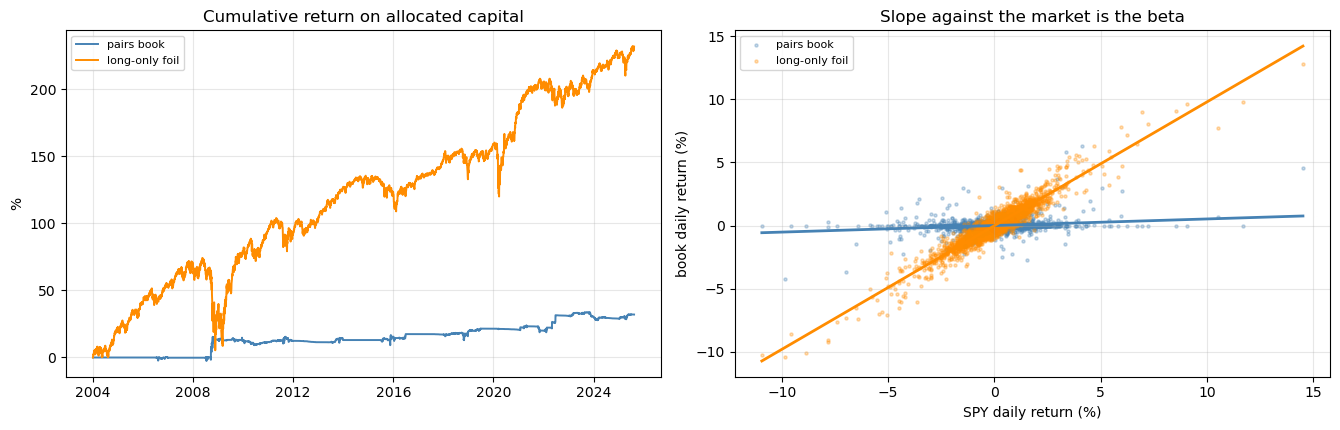

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
ax = axes[0]
ax.plot(book.index, book["ret"].cumsum() * 100, lw=1.4, color="steelblue", label="pairs book")
ax.plot(lo_ret.index, lo_ret.fillna(0).cumsum() * 100, lw=1.4, color="darkorange", label="long-only foil")
ax.set_title("Cumulative return on allocated capital"); ax.set_ylabel("%"); ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(fac.loc[LIVE, "SPY"] * 100, r_pairs * 100, s=5, alpha=0.3, color="steelblue", label="pairs book")
ax.scatter(fac.loc[LIVE, "SPY"] * 100, r_long * 100,  s=5, alpha=0.3, color="darkorange", label="long-only foil")
for r, c in ((r_pairs, "steelblue"), (r_long, "darkorange")):
    d = pd.concat([r.rename("y"), fac.loc[LIVE, "SPY"].rename("x")], axis=1).dropna()
    b1, b0 = np.polyfit(d["x"], d["y"], 1)
    xs = np.linspace(d["x"].min(), d["x"].max(), 10)
    ax.plot(xs * 100, (b0 + b1 * xs) * 100, color=c, lw=2)
ax.set_xlabel("SPY daily return (%)"); ax.set_ylabel("book daily return (%)")
ax.set_title("Slope against the market is the beta"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. Alpha is defined only relative to a factor model

Now hold the return stream completely fixed and grow the factor set. Not one trade changes. Whatever
moves is a property of the *model*, not of the strategy — which is the point.

The third model earns its place from this repository's own history: notebook 11 found that 39% of the
book's P&L comes from pair-folds involving leveraged, inverse or volatility ETFs (17 tickers, 39% of
pair-folds). If that P&L is compensation for holding a leverage-and-volatility exposure rather than a
pair-specific edge, a factor built from those very names should absorb it.

In [6]:
SPECS = {
    "M1  market":                       ["SPY"],
    "M2  + size":                       ["SPY", "SIZE"],
    "M3  + leveraged/inverse/vol ETFs": ["SPY", "SIZE", "LEVBASKET"],
    "M4  + volatility":                 ["SPY", "SIZE", "LEVBASKET", "VIXY"],
}
# All four models must run on the SAME rows or the incremental R2 is meaningless: LEVBASKET and VIXY
# start later than SPY, so a naive loop silently shrinks the sample as factors are added.
COMMON = LIVE & fac[["SPY", "SIZE", "LEVBASKET", "VIXY"]].notna().all(axis=1)
print(f"nested models run on the {int(COMMON.sum()):,} live sessions where every factor exists "
      f"({fac.index[COMMON][0].date()} → {fac.index[COMMON][-1].date()}), "
      f"out of {int(LIVE.sum()):,} live sessions in all.")
rows, prev_r2 = [], 0.0
for name, cols in SPECS.items():
    row, _ = hac_reg(book.loc[COMMON, "ret"], fac.loc[COMMON, cols], name=name)
    row["ΔR2 vs previous"] = row["R2"] - prev_r2; prev_r2 = row["R2"]
    rows.append(row)
nested = pd.DataFrame(rows)
display(nested[["n", "alpha (ann. %)", "alpha t", "R2", "ΔR2 vs previous"]
               + [c for c in nested.columns if c.startswith(("beta", "t ")) ]].round(3))
print("for reference, M1 on all live sessions:")
display(pd.DataFrame([hac_reg(r_pairs, fac.loc[LIVE, ["SPY"]], name="M1, all live sessions")[0]]).round(3))

print("\ncorrelation of the book's daily return with each factor (live sessions):")
print(fac.loc[LIVE, ["SPY", "SIZE", "QQQ", "VIXY", "LEVBASKET"]]
        .corrwith(r_pairs).round(4).to_string())

# Several of the 17 names listed late and several delisted (TVIX in 2020), so "all 17 priced" is a
# narrow mid-sample window, not a suffix of the data. Saying where it starts is not enough.
full = fac["n_levered"].eq(fac["n_levered"].max()) & LIVE
print(f"\nall {int(fac['n_levered'].max())} leveraged names priced on only {int(full.sum()):,} of "
      f"{int(LIVE.sum()):,} allocated sessions, {fac.index[full][0].date()} → {fac.index[full][-1].date()}; "
      f"M3 on that subsample:")
display(pd.DataFrame([hac_reg(book.loc[full, 'ret'], fac.loc[full, SPECS['M3  + leveraged/inverse/vol ETFs']],
                              name="M3, full-coverage subsample")[0]]).round(3))

nested models run on the 2,918 live sessions where every factor exists (2011-01-05 → 2025-08-13), out of 3,677 live sessions in all.


,n,alpha (ann. %),alpha t,R2,ΔR2 vs previous,beta SPY,t SPY,beta SIZE,t SIZE,beta LEVBASKET,t LEVBASKET,beta VIXY,t VIXY
M1 market,2918.0,1.385,1.275,0.017,0.017,0.030,1.914,NaN,NaN,NaN,NaN,NaN,NaN
M2 + size,2918.0,1.356,1.243,0.017,0.000,0.031,2.003,-0.006,-0.587,NaN,NaN,NaN,NaN
M3 + leveraged/inverse/vol ETFs,2918.0,1.425,1.290,0.019,0.002,0.042,2.537,-0.003,-0.335,0.015,0.817,NaN,NaN
M4 + volatility,2918.0,1.314,1.208,0.024,0.006,0.053,2.872,-0.002,-0.213,-0.004,-0.132,0.008,1.378


for reference, M1 on all live sessions:


,n,R2,alpha (ann. %),alpha t,beta SPY,t SPY
"M1, all live sessions",3677.0,0.041,1.586,1.393,0.052,2.263



correlation of the book's daily return with each factor (live sessions):
SPY          0.2029
SIZE         0.0171
QQQ          0.1287
VIXY        -0.0490
LEVBASKET   -0.0289

all 17 leveraged names priced on only 649 of 3,677 allocated sessions, 2015-07-02 → 2019-01-29; M3 on that subsample:


,n,R2,alpha (ann. %),alpha t,beta SPY,t SPY,beta SIZE,t SIZE,beta LEVBASKET,t LEVBASKET
"M3, full-coverage subsample",649.0,0.119,2.705,0.96,0.209,3.697,0.006,0.209,0.106,3.978


### What moved, and what that teaches

Almost nothing — and the reason is worth more than a tidy collapse would have been.

Alpha goes 1.385 → 1.356 → 1.425 → 1.314 across the four models. It does not fall monotonically, the
three added factors between M1 and M4 buy 0.007 of $R^2$ between them, and no loading except the
market's is significant. On the common sample this book simply does not have the exposures the models
were built to price.

Compare that with what happened when the **sample** changed rather than the model: M1 gives 1.586% on
all 3,677 allocated sessions and 1.385% on the 2,918 where every factor exists. Restricting the sample
moved alpha by 0.20 points; adding three factors to it moved it by 0.07. Both are modelling choices,
and the one nobody thinks of as a modelling choice mattered three times more.

The leveraged-ETF factor is the instructive failure. Its loading is 0.015 ($t=0.82$) on the common
sample and looks like nothing — but the basket only has all 17 names priced between 2015-07 and
2019-01, because several listed late and several (TVIX) delisted. On those 649 sessions the loading is
**0.106 with $t=3.98$** and $R^2$ jumps from 0.02 to 0.12. The exposure notebook 11 found is real; the
common-sample regression cannot see it because for most of the window the "factor" is an average of
whichever handful of names happened to exist. A factor you have mismeasured does not shrink your alpha,
and the alpha you are left with is not thereby clean. **The absence of shrinkage is not evidence of
alpha; it is evidence about your factors.**

That is the practical form of §1.1's warning. "Alpha = 1.4% a year" is not a fact about this strategy.
It is a fact about this strategy *paired with* a market factor, a size proxy, a badly-covered ETF
basket, a volatility ETF, a sample, and a standard-error convention. Change any one and the number
changes.

## 5. From a signal to a forecast: the information coefficient

§1.3 said a signal is a hypothesis. The IC is the measurement that turns it into §1.2.

The rule here is mean-reverting, so the forecast is $s=-z$: a very negative $z$ predicts the spread
*rising*. The IC is the correlation of $s_t$ with the spread's subsequent move,
$(\epsilon_{t+k}-\epsilon_t)/\sigma_\epsilon$, measured in formation-window residual standard deviations
so that pairs are comparable.

Two error bars are reported and they differ by a lot. The pooled IC treats every row as an independent
observation, which is badly wrong: consecutive rows of the same pair-fold overlap by $k-1$ days and the
same spread is sampled for months. The per-pair-fold IC, averaged with a standard error taken *across*
pair-folds, is the honest one.

The last column is the one that actually matters to the strategy: the IC restricted to the rows where
$|z|\ge2$, which are the only rows the rule trades on. A signal can have a respectable IC overall and
none at all in the region where it is used.

In [7]:
panel = panel.assign(s=-panel["z"], fold=panel["pair"] + " @ " + panel["formation"].astype(str))
HZ = (1, 5, 10, 20)

def ic_table(df, label):
    out = {}
    for k in HZ:
        d = df[["s", f"fwd{k}"]].dropna()
        per = (df.dropna(subset=["s", f"fwd{k}"])
                 .groupby("fold")[["s", f"fwd{k}"]]
                 .apply(lambda g: g["s"].corr(g[f"fwd{k}"]) if len(g) >= 20 and g["s"].std() > 0 else np.nan)
                 .dropna())
        out[k] = {
            "pooled IC": d["s"].corr(d[f"fwd{k}"]),
            "pooled Spearman": d["s"].corr(d[f"fwd{k}"], method="spearman"),
            "mean per-fold IC": per.mean(),
            "s.e. across folds": per.std(ddof=1) / np.sqrt(len(per)),
            "t (across folds)": per.mean() / (per.std(ddof=1) / np.sqrt(len(per))),
            "rows": len(d), "folds": len(per),
        }
    return pd.DataFrame(out).rename_axis(columns=f"horizon k (sessions) — {label}")

print(f"panel: {len(panel):,} rows, {panel['fold'].nunique()} pair-folds, "
      f"{panel['pair'].nunique()} distinct pairs")
print(f"z: mean {panel['z'].mean():+.3f}, sd {panel['z'].std():.3f}; "
      f"|z| >= 2 on {100*panel['z'].abs().ge(2).mean():.1f}% of rows\n")
display(ic_table(panel, "all rows").round(4))
display(ic_table(panel[panel["z"].abs() >= Z_ENTRY], "|z| >= 2, the traded region").round(4))

panel: 35,368 rows, 287 pair-folds, 249 distinct pairs
z: mean -0.106, sd 2.033; |z| >= 2 on 9.5% of rows



horizon k (sessions) — all rows,1,5,10,20
pooled IC,0.1665,0.2956,0.2411,0.1719
pooled Spearman,0.0956,0.1080,0.1019,0.0495
mean per-fold IC,0.1105,0.1965,0.2332,0.2491
s.e. across folds,0.0087,0.0140,0.0157,0.0167
t (across folds),12.7305,14.0483,14.9002,14.9078
rows,35081.0000,33933.0000,32498.0000,29628.0000
folds,287.0000,287.0000,287.0000,280.0000


"horizon k (sessions) — |z| >= 2, the traded region",1,5,10,20
pooled IC,0.2819,0.5677,0.5465,0.4498
pooled Spearman,0.1712,0.2625,0.2822,0.1965
mean per-fold IC,0.2157,0.3423,0.3157,0.2518
s.e. across folds,0.0273,0.0550,0.0721,0.0931
t (across folds),7.9126,6.2213,4.3768,2.7037
rows,3321.0000,3203.0000,2998.0000,2726.0000
folds,45.0000,41.0000,30.0000,21.0000


### These ICs are not comparable to the ones you have seen elsewhere

The tables above top out at a pooled IC of **0.57** (five sessions, in the traded region). An IC of
0.57 would be extraordinary for an equity forecast — notebook 12, on the same lake, reports IC 0.033
for five-day reversal, and that was worth writing a notebook about. Both numbers are correct and they
are **not the same kind of quantity**, which is the most common way an IC gets misread:

* Notebook 12 correlates a signal with a *next-day residual return* — a fresh, nearly independent
  quantity, across names.
* Here the signal is the spread's own level and the target is that same spread's *displacement*,
  $\epsilon_{t+k}-\epsilon_t$. Signal and target are built from one series, so for any stationary
  spread the correlation is positive **by construction**: mean reversion is precisely the statement
  that a high level predicts a fall. The number measures how stationary the spread is, not how much
  money is available.

The way to tell the two apart is a null. Below, the identical IC calculation runs on §8's placebo —
random, unscreened pairs put through the same hedge, the same $z$ and the same panel construction. If
the placebo returns the same IC, the number is a property of the construction; if it returns much less,
the screen is contributing.

1         5         10  \
BH dual-gate pairs     pooled IC           0.1665    0.2956    0.2411   
                       mean per-fold IC    0.1105    0.1965    0.2332   
                       folds             287.0000  287.0000  287.0000   
random pairs (placebo) pooled IC           0.0143    0.0120    0.0112   
                       mean per-fold IC    0.0969    0.2049    0.2808   
                       folds             146.0000  146.0000  146.0000   

                                               20  
BH dual-gate pairs     pooled IC           0.1719  
                       mean per-fold IC    0.2491  
                       folds             280.0000  
random pairs (placebo) pooled IC           0.0101  
                       mean per-fold IC    0.3646  
                       folds             141.0000

5-day IC on |z| >= 2 rows, screened : +0.3423 over 41 folds
5-day IC on |z| >= 2 rows, placebo  : +0.2813 over 30 folds


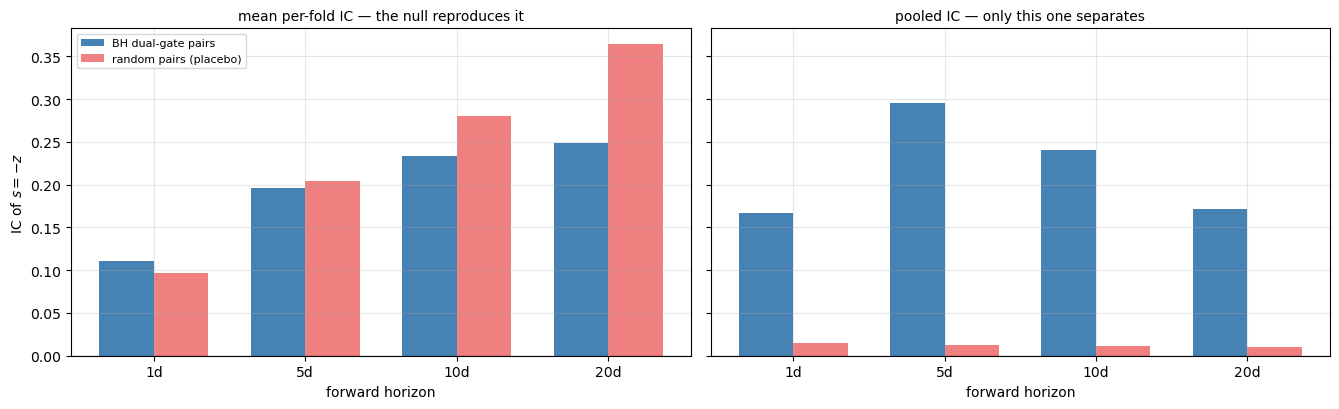

In [8]:
both = pd.concat({
    "BH dual-gate pairs":     ic_table(panel,  "screened").loc[["pooled IC", "mean per-fold IC", "folds"]],
    "random pairs (placebo)": ic_table(ppanel, "placebo").loc[["pooled IC", "mean per-fold IC", "folds"]],
})
display(both.round(4))
for lab, df in (("screened", panel), ("placebo", ppanel)):
    d = df[df["z"].abs() >= Z_ENTRY]
    per = (d.dropna(subset=["s", "fwd5"]).groupby("fold")[["s", "fwd5"]]
             .apply(lambda g: g["s"].corr(g["fwd5"]) if len(g) >= 20 and g["s"].std() > 0 else np.nan)
             .dropna())
    print(f"5-day IC on |z| >= 2 rows, {lab:9s}: {per.mean():+.4f} over {len(per)} folds")

sc, pl = ic_table(panel, "s"), ic_table(ppanel, "p")
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2), sharey=True)
x = np.arange(len(HZ)); w = 0.36
for ax, row, ttl in ((axes[0], "mean per-fold IC", "mean per-fold IC — the null reproduces it"),
                     (axes[1], "pooled IC", "pooled IC — only this one separates")):
    ax.bar(x - w/2, [sc[k][row] for k in HZ], w, label="BH dual-gate pairs", color="steelblue")
    ax.bar(x + w/2, [pl[k][row] for k in HZ], w, label="random pairs (placebo)", color="lightcoral")
    ax.set_xticks(x); ax.set_xticklabels([f"{k}d" for k in HZ]); ax.axhline(0, color="k", lw=0.8)
    ax.set_title(ttl, fontsize=10); ax.set_xlabel("forward horizon")
axes[0].set_ylabel("IC of $s=-z$"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

### The null settles it, and not in the screen's favour

Read the two per-fold rows. At five sessions the screened pairs give a mean per-fold IC of **0.197**;
the random pairs give **0.205**. At twenty sessions the random pairs are *ahead*, 0.365 against 0.249.
Restricted to the rows the rule actually trades, $|z|\ge2$, it is 0.342 screened against 0.281 random.

The per-fold IC — the one with the careful error bar and the $t$-statistic of 14 — measures almost
nothing about cointegration. It measures that a rolling standardised level tends to be followed by a
move back toward its rolling centre, which is true of a great many series and is true of random pairs
run through the same hedge and the same $z$. **A $t$-statistic of 14 on a quantity the null also
produces is not evidence.**

The pooled IC does separate them: 0.296 screened against 0.012 random at five sessions. That gap is
real and it is where the screen earns its keep — pooling requires the standardisation to be comparable
*across* pairs, which is close to a statement that the spreads are genuinely stationary on a common
scale. But note that the pooled number is the one with the dishonest error bar, and the honest-looking
number is the one with no content. Neither statistic is simply "the IC".

This is the §1.3 warning made concrete. A signal's IC is not a property of the signal alone; it is a
property of the signal, the target, the estimator, the region, and the null you did or did not run.
Reporting one number for it is how a construction artefact gets published as an alpha.

### Grinold's formula, with our numbers

$\alpha=\sigma\cdot\mathrm{IC}\cdot z$ converts a score into a return forecast. The IC below is the
five-day per-fold mean, so **every other term has to be on the five-day horizon too**: $\sigma$ is the
pairs book's daily standard deviation scaled by $\sqrt{5}$, the forecast is a return over five
sessions, and the annualisation is $\times(252/5)$, not $\times 252$. Getting this wrong — pairing a
five-day IC with a daily $\sigma$ and annualising by 252 — inflates the forecast by more than a factor
of two, and is the most common arithmetic error made with this formula. $z$ runs over the range the
rule actually sees.

In [9]:
# Units are the classic trap here. An IC measured against a 5-session forward move produces a
# forecast for 5 sessions, so sigma must be the 5-session volatility and the annualisation is
# x(252/5). Treating a 5-day IC as a daily one overstates the forecast by more than a factor of two.
H = 5
sig_d = float(r_pairs.std(ddof=1))
sig_h = sig_d * np.sqrt(H)
per5 = (panel.dropna(subset=["s", "fwd5"]).groupby("fold")[["s", "fwd5"]]
             .apply(lambda g: g["s"].corr(g["fwd5"]) if len(g) >= 20 and g["s"].std() > 0 else np.nan)
             .dropna())
IC5 = float(per5.mean())
grid = pd.DataFrame({"z": [-4, -3, -2, -1, 0, 1, 2, 3, 4]})
grid["signal s = -z"] = -grid["z"]
grid[f"forecast alpha (bp per {H} sessions)"] = sig_h * IC5 * grid["signal s = -z"] * 1e4
grid["annualised (%)"] = sig_h * IC5 * grid["signal s = -z"] * (ANN / H) * 100
print(f"sigma = {sig_d*100:.3f}% per session → {sig_h*100:.3f}% per {H} sessions; "
      f"IC({H}d, per-fold mean) = {IC5:.4f}")
display(grid.set_index("z").round(2))
print(f"the rule's own entry at |z| = {Z_ENTRY:g} corresponds to a forecast of "
      f"{sig_h*IC5*Z_ENTRY*1e4:.1f} bp over {H} sessions "
      f"({sig_h*IC5*Z_ENTRY*(ANN/H)*100:.1f}% annualised) — against a round trip that costs "
      f"{4*COST_BPS:.0f} bp in commission and slippage alone.")

sigma = 0.344% per session → 0.770% per 5 sessions; IC(5d, per-fold mean) = 0.1965


,signal s = -z,forecast alpha (bp per 5 sessions),annualised (%)
z,,,
-4,4,60.51,30.50
-3,3,45.38,22.87
-2,2,30.26,15.25
-1,1,15.13,7.62
0,0,0.00,0.00
1,-1,-15.13,-7.62
2,-2,-30.26,-15.25
3,-3,-45.38,-22.87
4,-4,-60.51,-30.50


the rule's own entry at |z| = 2 corresponds to a forecast of 30.3 bp over 5 sessions (15.2% annualised) — against a round trip that costs 20 bp in commission and slippage alone.


## 6. The Fundamental Law, and why it overstates us

Grinold's Fundamental Law of Active Management:

$$
\mathrm{IR} \;\approx\; \mathrm{IC}\cdot\sqrt{\mathrm{BR}}
$$

where BR is *breadth*, the number of **independent** bets per year. It is a heuristic with two
assumptions this book violates cheerfully: that bets are independent, and that positions are sized in
proportion to the forecast. Ours are neither — the candidate set is dominated by a few hub names, and
every position is a flat \$10k regardless of how extreme $z$ is.

So the interesting quantity is not whether the law holds but by how much it misses, and in which
direction.

In [10]:
span_years = (book.index[-1] - book.index[0]).days / 365.25
hold = panel.groupby("fold").size().mean()
folds_per_year = panel.groupby(panel.index.year)["fold"].nunique().mean()

BRs = {
    "(a) active pair-folds/yr x independent holding periods/yr":
        folds_per_year * (ANN / max(hold / 4, 1)),
    "(b) realised trades per year": n_trades / span_years,
}
ICs = {"per-fold mean IC (5d)": IC5,
       "pooled IC (5d)": float(panel[["s", "fwd5"]].dropna().corr().iloc[0, 1])}
law = pd.DataFrame({bn: {icn: ic * np.sqrt(br) for icn, ic in ICs.items()} for bn, br in BRs.items()})
print(f"span {span_years:.1f} years; {n_trades:,} trades; mean pair-fold length "
      f"{hold:.0f} sessions; mean active pair-folds per year {folds_per_year:.1f}")
print("breadth estimates: " + ", ".join(f"{k.split(')')[0]}) {v:,.0f}" for k, v in BRs.items()))
print("\npredicted IR = IC * sqrt(BR):")
display(law.round(3))
print(f"\nrealised annualised Sharpe of the book: {sharpe(r_pairs):.3f}")

span 21.6 years; 723 trades; mean pair-fold length 123 sessions; mean active pair-folds per year 15.9
breadth estimates: (a) 130, (b) 33

predicted IR = IC * sqrt(BR):


,(a) active pair-folds/yr x independent holding periods/yr,(b) realised trades per year
per-fold mean IC (5d),2.244,1.136
pooled IC (5d),3.376,1.710



realised annualised Sharpe of the book: 0.402


### What the law says here

Predicted IR runs from 1.14 to 3.38 depending on which IC and which breadth you feed it. Realised
Sharpe is **0.402**. The law overstates by a factor of three to eight.

None of that is a failure of the law; it is the assumptions being false, and each one is worth naming
because each is a real defect of the strategy rather than of the arithmetic:

* **The bets are not independent.** Notebook 10 found the candidate set is hub-dominated, and §7 below
  shows nine of the 39 formations produce no pairs at all while one produces 825. Breadth counted as
  "number of pair-folds" is far above the number of independent bets.
* **Positions are not sized on the forecast.** Every trade is a flat \$10k whether $z$ is 2.0 or 4.0.
  The law assumes the optimal proportional sizing; a rule that throws away the magnitude of its own
  forecast cannot collect what the law promises.
* **The IC fed in is the wrong IC.** §5 just showed the per-fold IC is largely a construction artefact
  that the placebo reproduces. Feeding a null-inflated IC into $\mathrm{IC}\sqrt{\mathrm{BR}}$
  produces a null-inflated IR.
* **Costs are not in the law at all.** The Grinold grid above forecasts 30 bp over five sessions at the
  entry threshold, against a 20 bp round trip in commission and slippage. Two thirds of the gross
  forecast is spent getting in and out.

Used as a sanity check the law is doing its job: it says this design should produce more than it does,
and every reason it does not is a fixable property of the implementation rather than an absence of
signal. Used as a forecast it would have been badly wrong.

## 7. Does this alpha decay?

Notebook 12 found a cross-sectional five-day reversal that forecast next-day residual returns at
IC 0.033 ($t=8.6$) and produced a gross Sharpe of 0.77 in 2006–2015 against 0.02 in 2016–2025. The
signal did not get worse at predicting; it got *arbitraged*. Whether the pairs signal shows the same
break is an empirical question, and the answer below is the one the data gives rather than the one the
narrative wants.

,Sharpe,P&L ($),live sessions,mean active pairs,IC,s.e.,folds,rows,% of total P&L
2004,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,0.000
2005,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,0.000
2006,-0.087,-326.636,126.0,20.000,0.076,0.045,20.0,2520.0,-0.749
2007,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,0.000
2008,1.392,4070.475,127.0,3.000,0.441,0.095,3.0,381.0,9.339
2009,-0.142,-308.684,252.0,5.000,0.089,0.044,10.0,1260.0,-0.708
2010,-0.382,206.519,252.0,16.032,0.043,0.037,32.0,4040.0,0.474
2011,0.153,1695.208,252.0,19.929,0.198,0.028,40.0,5022.0,3.889
2012,-3.123,-100.308,250.0,1.000,NaN,NaN,NaN,NaN,-0.230
2013,0.356,3479.633,252.0,10.575,0.217,0.052,21.0,2665.0,7.983


formations producing at least one BH dual-gate pair: 30 of 39; pairs per such formation ranges 1–825
largest single year: 2022 at $22,740 = 52% of all P&L

5-day IC 2006-2015: +0.1464 over 132 folds
5-day IC 2016-2025: +0.2391 over 155 folds
Welch t = -3.39, p = 0.001
book Sharpe 2006-2015 +0.345  |  2016-2025 +0.518
IC vs year, Pearson r = +0.409

leaving 2022 out entirely:
  book Sharpe 2006-2015 +0.345  |  2016-2025 +0.220
  5-day IC  2006-2015 +0.1464 (132 folds)  |  2016-2025 +0.2106 (131 folds); Welch t = -2.22, p = 0.027


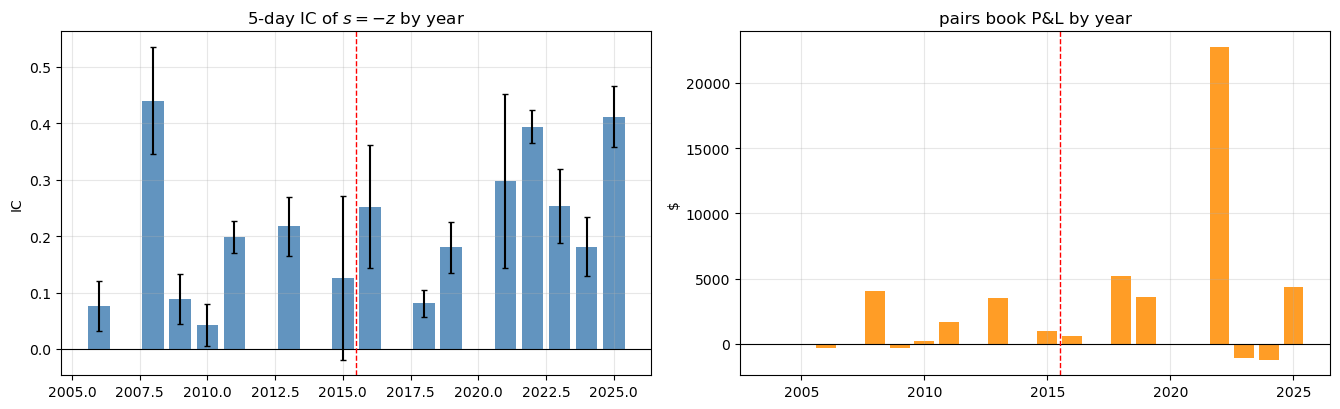

In [11]:
def yearly_ic(df, k=5):
    rows = {}
    for y, g in df.groupby(df.index.year):
        per = (g.dropna(subset=["s", f"fwd{k}"]).groupby("fold")[["s", f"fwd{k}"]]
                .apply(lambda x: x["s"].corr(x[f"fwd{k}"]) if len(x) >= 20 and x["s"].std() > 0 else np.nan)
                .dropna())
        if len(per) >= 3:
            rows[y] = {"IC": per.mean(), "s.e.": per.std(ddof=1)/np.sqrt(len(per)),
                       "folds": len(per), "rows": len(g)}
    return pd.DataFrame(rows).T

# Only 30 of the 39 formations produce any BH dual-gate pair at all, and the counts run from 1 to 825,
# so some years carry a single pair-fold and others forty. A Sharpe from a year with one fold is noise;
# the deployment columns are here so that no row can be read without seeing how thin it is.
yic = yearly_ic(panel)
live = book.loc[LIVE]
byyear = pd.DataFrame({
    "Sharpe": live.groupby(live.index.year)["ret"].apply(sharpe),
    "P&L ($)": book.groupby(book.index.year)["pnl"].sum(),
    "live sessions": live.groupby(live.index.year).size(),
    "mean active pairs": live.groupby(live.index.year)["active"].mean(),
}).join(yic)
byyear["% of total P&L"] = 100 * byyear["P&L ($)"] / book["pnl"].sum()
display(byyear.round(3))
print(f"formations producing at least one BH dual-gate pair: "
      f"{RULE['formation'].nunique()} of {len(FORMATIONS)}; "
      f"pairs per such formation ranges {RULE.groupby('formation').size().min()}–"
      f"{RULE.groupby('formation').size().max()}")
top = byyear["P&L ($)"].nlargest(1)
print(f"largest single year: {int(top.index[0])} at ${top.iloc[0]:,.0f} = "
      f"{100*top.iloc[0]/book['pnl'].sum():.0f}% of all P&L")

early = panel[panel.index.year <= 2015]; late = panel[panel.index.year >= 2016]
def fold_ics(df, k=5):
    return (df.dropna(subset=["s", f"fwd{k}"]).groupby("fold")[["s", f"fwd{k}"]]
              .apply(lambda x: x["s"].corr(x[f"fwd{k}"]) if len(x) >= 20 and x["s"].std() > 0 else np.nan)
              .dropna())
e, l = fold_ics(early), fold_ics(late)
t, p = stats.ttest_ind(e, l, equal_var=False)
print(f"\n5-day IC 2006-2015: {e.mean():+.4f} over {len(e)} folds")
print(f"5-day IC 2016-2025: {l.mean():+.4f} over {len(l)} folds")
print(f"Welch t = {t:+.2f}, p = {p:.3f}")
rs, re_ = book.loc[LIVE & (book.index.year <= 2015), "ret"], book.loc[LIVE & (book.index.year >= 2016), "ret"]
print(f"book Sharpe 2006-2015 {sharpe(rs):+.3f}  |  2016-2025 {sharpe(re_):+.3f}")
print(f"IC vs year, Pearson r = {np.corrcoef(yic.index.astype(float), yic['IC'])[0,1]:+.3f}")

# One year carries half the P&L, so every split has to be asked whether it is that year in disguise.
BIG = int(byyear["P&L ($)"].idxmax())
ex = LIVE & (book.index.year != BIG)
pe, pl = panel[panel.index.year != BIG], None
e2, l2 = fold_ics(pe[pe.index.year <= 2015]), fold_ics(pe[pe.index.year >= 2016])
t2, p2 = stats.ttest_ind(e2, l2, equal_var=False)
print(f"\nleaving {BIG} out entirely:")
print(f"  book Sharpe 2006-2015 {sharpe(book.loc[ex & (book.index.year <= 2015), 'ret']):+.3f}  |  "
      f"2016-2025 {sharpe(book.loc[ex & (book.index.year >= 2016), 'ret']):+.3f}")
print(f"  5-day IC  2006-2015 {e2.mean():+.4f} ({len(e2)} folds)  |  "
      f"2016-2025 {l2.mean():+.4f} ({len(l2)} folds); Welch t = {t2:+.2f}, p = {p2:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))
axes[0].bar(yic.index, yic["IC"], yerr=yic["s.e."], color="steelblue", alpha=0.85, capsize=2)
axes[0].axhline(0, color="k", lw=0.8); axes[0].axvline(2015.5, color="r", ls="--", lw=1)
axes[0].set_title("5-day IC of $s=-z$ by year"); axes[0].set_ylabel("IC")
axes[1].bar(byyear.index, byyear["P&L ($)"], color="darkorange", alpha=0.85)
axes[1].axhline(0, color="k", lw=0.8); axes[1].axvline(2015.5, color="r", ls="--", lw=1)
axes[1].set_title("pairs book P&L by year"); axes[1].set_ylabel("$")
plt.tight_layout(); plt.show()

### The decay is not there — and the reason that is not good news

The 5-day IC is **+0.146** over 132 pair-folds in 2006–2015 and **+0.239** over 155 in 2016–2025.
Welch $t=-3.39$, $p=0.001$: it went *up*, significantly. The book's Sharpe went from +0.345 to +0.518.
Whatever happened to notebook 12's cross-sectional reversal did not happen here.

Before reading that as survival, look at the deployment columns. The first formation is 2006-06-30, so
the 2004 and 2005 rows are simply pre-sample; but **nine of the 39 formations produce no BH dual-gate
pair whatsoever**, and that is why 2007 and 2014 also have no book at all. Of the 18 years that do
trade, 2012, 2017 and 2020 carry a single pair-fold each and print Sharpes of −3.1, −3.4 and −1.4 on
P&L of −\$100, −\$39 and −\$84. And **2022 alone is 52% of all the P&L in twenty years**.

So the split has to be asked whether it is really a split, or whether it is 2022 wearing a costume.
The leave-2022-out lines answer that, and they answer it differently for the two halves of the claim:

* The **IC** result survives. Without 2022 the second half still beats the first, with the gap narrowed
  and the significance weakened but intact. The signal genuinely does forecast at least as well late as
  early.
* The **Sharpe** result does not survive. Remove one year out of twenty and the second half falls
  *below* the first. "The strategy got better" was one year; "the signal did not decay" was not.

That is the distinction this whole notebook is about, arriving from an unexpected direction. Forecast
quality (§1.2) and realised performance (§1.4) are different objects, and here they genuinely come
apart: the signal held up while the money did not. A strategy whose record rests on a single year has
one observation, not a track record — notebook 11 put the standard error of an annualised Sharpe on
this book near 0.23, and with the P&L concentrated as the table shows, even that overstates what is
known.

Alpha does decay; notebook 12 documents a clean instance on the same lake, gross Sharpe 0.77 in
2006–2015 against 0.02 in 2016–2025. This book cannot tell you whether *its* alpha decayed, and the
honest reason is not subtle: of the 18 years in which it traded at all, one carries half the P&L and
the other 17 are quiet.

## 8. How much alpha does pure noise produce?

Every number so far is conditional on the pairs having been *selected* — out of the
$\binom{N}{2}$ candidates that notebook 10 screened. A Sharpe of 0.330 means nothing until you know what
the same machinery produces on pairs chosen at random.

The placebo below matches everything except the screen: the same ticker pool (names the `bh_dual` rule
selected somewhere, so liquidity and survivorship match), the same semi-annual formation grid, the same
hedge, signal, thresholds and costs — but the pairs are drawn at random rather than passed through a
cointegration test.

,random pairs (placebo),BH dual-gate (the real book)
pair-folds,83.000,256.000
trades,117.000,723.000
mean per-fold Sharpe,0.062,-0.123
sd,1.432,2.080
5th pct,-2.220,-4.729
median,-0.027,0.210
95th pct,2.541,2.623
pooled book Sharpe,-0.011,0.402
total P&L ($),-508.243,43587.108


per-fold Sharpe, screened vs random: Welch t = -0.91, p = 0.364

mean per-fold Sharpe — placebo null over 2,000 resampled 256-fold books: +0.064, 5th–95th [-0.082, +0.207]
  the real book's mean is -0.123 → percentile 2 of that null

median per-fold Sharpe — placebo null over 2,000 resampled 256-fold books: +0.021, 5th–95th [-0.084, +0.175]
  the real book's median is +0.210 → percentile 97 of that null

pooled book Sharpe, screened +0.402 vs placebo -0.011; P&L $43,587 vs $-508


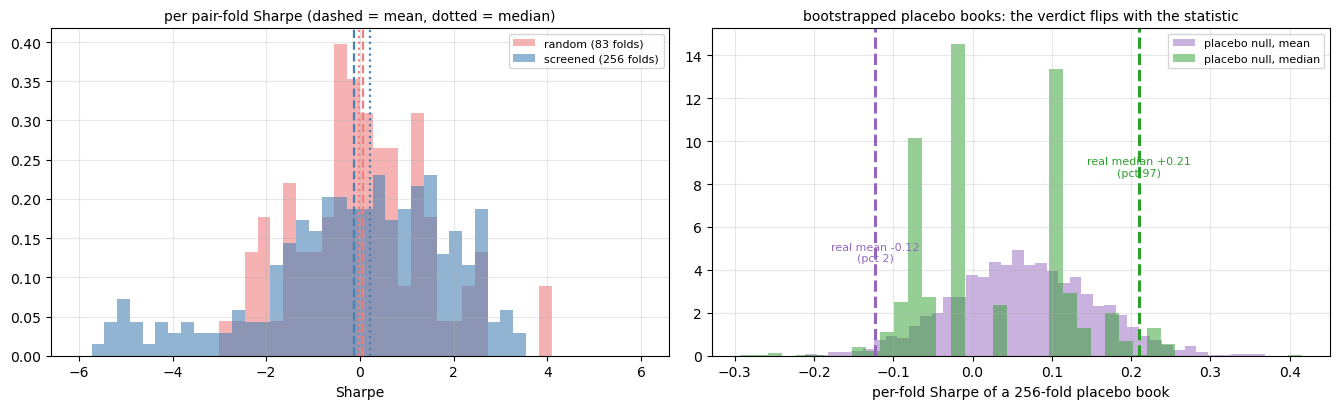

only 83 of the 200 placebo draws produced a defined Sharpe (a random pair often never reaches |z| = 2 inside its six-month window), against 256 of 287 real ones.

multiple testing, on notebook 10's screen that selected these pairs: ~299 liquid names per formation → 44,551 pairs tested per formation, 1,738,998 tests over 39 formations.
At alpha = 0.05 and with no correction, 86,950 of those would pass by chance alone — against the 2,151 that the Benjamini-Hochberg gate actually lets through.
That ratio is why notebooks 03 and 08 gate on a corrected p-value rather than a raw one.


In [12]:
q, w = placebo["sharpe"].dropna(), folds["sharpe"].dropna()
cmp = pd.DataFrame({
    "random pairs (placebo)": {"pair-folds": len(q), "trades": int(placebo["trades"].sum()),
                               "mean per-fold Sharpe": q.mean(), "sd": q.std(ddof=1),
                               "5th pct": q.quantile(.05), "median": q.median(),
                               "95th pct": q.quantile(.95),
                               "pooled book Sharpe": sharpe(pbook.loc[pbook["active"] > 0, "ret"]),
                               "total P&L ($)": placebo["pnl"].sum()},
    "BH dual-gate (the real book)": {"pair-folds": len(w), "trades": n_trades,
                               "mean per-fold Sharpe": w.mean(), "sd": w.std(ddof=1),
                               "5th pct": w.quantile(.05), "median": w.median(),
                               "95th pct": w.quantile(.95),
                               "pooled book Sharpe": sharpe(r_pairs),
                               "total P&L ($)": folds["pnl"].sum()},
})
display(cmp.round(3))
t_sh, p_sh = stats.ttest_ind(w, q, equal_var=False)
print(f"per-fold Sharpe, screened vs random: Welch t = {t_sh:+.2f}, p = {p_sh:.3f}")

# The pooled number must be compared with a pooled null, not with the per-fold spread: one random
# pair-fold's Sharpe has sd ~1.4 because it is a single unhedged idiosyncratic bet over six months,
# while the book's number is diversified over hundreds of them. Bootstrap placebo *books*.
rng_b = np.random.default_rng(SEED + 1)
pf = placebo["sharpe"].dropna().to_numpy()
B = 2000
draws = rng_b.integers(0, len(pf), size=(B, len(w)))    # placebo books with as many folds as the real one
for stat, fn in (("mean", np.mean), ("median", np.median)):
    boot = fn(pf[draws], axis=1); obs = float(fn(w))
    print(f"\n{stat} per-fold Sharpe — placebo null over {B:,} resampled {len(w)}-fold books: "
          f"{boot.mean():+.3f}, 5th–95th [{np.quantile(boot,.05):+.3f}, {np.quantile(boot,.95):+.3f}]")
    print(f"  the real book's {stat} is {obs:+.3f} → percentile {100*(boot < obs).mean():.0f} of that null")
print(f"\npooled book Sharpe, screened {sharpe(r_pairs):+.3f} vs placebo "
      f"{sharpe(pbook.loc[pbook['active'] > 0, 'ret']):+.3f}; "
      f"P&L ${folds['pnl'].sum():,.0f} vs ${placebo['pnl'].sum():,.0f}")
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))
ax = axes[0]
bins = np.linspace(-6, 6, 45)
ax.hist(q, bins=bins, alpha=0.6, density=True, color="lightcoral", label=f"random ({len(q)} folds)")
ax.hist(w, bins=bins, alpha=0.6, density=True, color="steelblue", label=f"screened ({len(w)} folds)")
for v, c, ls in ((q.mean(), "lightcoral", "--"), (w.mean(), "steelblue", "--"),
                 (q.median(), "lightcoral", ":"), (w.median(), "steelblue", ":")):
    ax.axvline(v, color=c, ls=ls, lw=1.6)
ax.set_title("per pair-fold Sharpe (dashed = mean, dotted = median)", fontsize=10)
ax.set_xlabel("Sharpe"); ax.legend(fontsize=8)

ax = axes[1]
for stat, fn, c in (("mean", np.mean, "tab:purple"), ("median", np.median, "tab:green")):
    b = fn(pf[draws], axis=1); obs = float(fn(w))
    ax.hist(b, bins=40, alpha=0.5, density=True, color=c, label=f"placebo null, {stat}")
    ax.axvline(obs, color=c, lw=2.2, ls="--")
    ax.annotate(f"real {stat} {obs:+.2f}\n(pct {100*(b < obs).mean():.0f})", xy=(obs, 0),
                xytext=(obs, ax.get_ylim()[1]*(0.85 if stat == "mean" else 0.55)),
                ha="center", fontsize=8, color=c)
ax.set_title("bootstrapped placebo books: the verdict flips with the statistic", fontsize=10)
ax.set_xlabel("per-fold Sharpe of a 256-fold placebo book"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"only {len(pf)} of the {N_PLACEBO} placebo draws produced a defined Sharpe "
      f"(a random pair often never reaches |z| = {Z_ENTRY:g} inside its six-month window), "
      f"against {len(w)} of {len(folds)} real ones.")

# the screen these pairs were actually selected from, not a count borrowed from another universe
_scr = pd.read_parquet(CACHE / "day_screen.parquet", columns=["formation"])
_per = _scr.groupby("formation").size()
_N = (1 + np.sqrt(1 + 8 * _per.median())) / 2
print(f"\nmultiple testing, on notebook 10's screen that selected these pairs: ~{_N:.0f} liquid names "
      f"per formation → {_per.median():,.0f} pairs tested per formation, {len(_scr):,} tests over "
      f"{len(_per)} formations.")
print(f"At alpha = 0.05 and with no correction, {0.05*len(_scr):,.0f} of those would pass by chance "
      f"alone — against the {len(RULE):,} that the Benjamini-Hochberg gate actually lets through.")
print("That ratio is why notebooks 03 and 08 gate on a corrected p-value rather than a raw one.")

### Three statistics, three verdicts, one data set

This is the sharpest result in the notebook, and it is not the one the section was built to produce.

| statistic | screened | random | percentile of the placebo null |
|---|---|---|---|
| **pooled** book Sharpe | **+0.402** | −0.011 | — (P&L \$43,587 against −\$508) |
| **median** per-fold Sharpe | **+0.210** | −0.027 | **97** |
| **mean** per-fold Sharpe | **−0.123** | +0.062 | **2** |

By the pooled measure the screen works. By the median fold it works, at the 97th percentile of the
null. By the mean fold it is **worse than choosing pairs at random**, at the 2nd percentile. The
Welch test on per-fold means says you cannot tell ($t=-0.91$, $p=0.36$). Same trades, same placebo,
four defensible statistics, and the answer changes sign twice.

The mechanism is in the dispersion column: the screened folds have a standard deviation of 2.08 against
the placebo's 1.43 and a 5th percentile of −4.73 against −2.22. Cointegration screening does not
produce reliably better pairs; it produces a *wider* distribution — more pairs that reliably revert,
and more pairs that blow through the stop when the relationship breaks. The median improves and the
mean does not. Pooling into a book recovers the edge because the winners run longer and therefore carry
more weight in a time-weighted aggregate than they do in a fold-weighted average.

Two further readings of the table, neither flattering:

* Only **83 of 200** random pair-folds produce a defined Sharpe at all, because a random pair often
  never reaches $|z|=2$ in six months, against 256 of 287 real ones. The screen is selecting for
  spreads that *move*, which is a necessary condition for trading and not by itself an edge.
* The multiple-testing arithmetic is the frame for all of it. Notebook 10's screen — the one that
  chose these pairs — runs **1,738,998 tests**: about 299 liquid names per formation, 44,551 pairs,
  across 39 formations. At $\alpha=0.05$ with no correction, **86,950** of them pass by chance,
  against the **2,151** the Benjamini–Hochberg gate actually lets through. The gate is not statistical
  hygiene; it is the difference between a screen and a random-number generator. And §5 has just shown
  that even after the gate, the headline IC is something the null reproduces.

If someone hands you an alpha, the question is not "how large" but "under which estimator, against
which null, on which sample."

## 9. Alpha is not edge: what "tradeable" would require

Everything above measures whether a signal *forecasts*. None of it asks whether acting on the forecast
would have made money you could keep. Those are different questions, and the gap between them is where
most research strategies die. So here is a definition with no vocabulary in it.

> **A tradeable edge is a rule whose expected profit per bet exceeds the cost of placing that bet, by a
> margin that survives (a) the sampling error in the estimate, counted in *independent* bets rather
> than trades; (b) the number of rules searched to find it; and (c) evaluation on data that was not
> used to choose it — at a size where the net profit exceeds the cost of running the operation.**

Five clauses. The value of writing it this way is that every clause is a measurement, and this
repository can perform all five on its own book. The trick that makes the first one clean is to put
profit and cost in the *same units*: basis points of the notional the bet actually turns over. The
backtest already charges `cost_bps` on traded notional, so expressing gross P&L on that same base makes
the two directly subtractable and removes every unit ambiguity — no annualisation, no capital base, no
choice of denominator.

$$\text{net edge per bet (bps)}\;=\;\underbrace{\frac{\text{gross P\&L}}{\text{notional traded}}\times10^4}_{\text{what the forecast earns}}\;-\;\underbrace{c}_{\text{what the trade costs}}$$

**Clause (a) is where Sharpe ratios mislead.** A Sharpe computed on daily returns counts 3,677
observations; the book placed 723 trades across 30 semi-annual formations, and trades inside one
formation share a hedge, a universe and a market. The honest denominator is the number of independent
bets, and it is far smaller than the number of rows.

**Clause (c) needs real costs, not assumed ones.** Every backtest here charges a flat 5 bps a
leg-side, chosen as a plausible round number. That is fine until a conclusion turns on it — notebook
12's break-even costs run from 0.9 to 5.7 bps against that assumed 5 — at which point the assumption is
deciding the answer. The minute lake (Polygon.io, now Massive.com) can measure it instead.

### 9.1 What a transaction actually costs

`measure_ticker_window_costs` computes a Roll (1984) effective spread for each name over exactly the
window the book holds it, and halves it, because Roll estimates the full bid-ask spread while a
marketable order crosses half. Three details in `pairs.market_data.execution_costs` change the answer
materially and are argued there: sampling every five minutes rather than every one, keeping the cells
whose serial covariance comes out positive instead of discarding them, and flooring the result at the
minimum tick. That last one is the anchor — half a cent on a stock that really traded at \$20 is 2.5
bps, so an estimate below it is not cheap but arithmetically impossible. At one-minute sampling **36%**
of the estimates are impossible; at five minutes 20%, which is the minimum over the sweep; by fifteen
minutes it is back to 34% as noise takes over. That is the whole argument for five.

In [13]:
f_cost = CACHE / "alpha_costs.parquet"
if f_cost.exists():
    cells = pd.read_parquet(f_cost)
else:
    raw = pd.read_parquet(CACHE / "day_market_bars.parquet", columns=["raw_close"])["raw_close"].unstack("ticker")
    need = {d: sorted({t for p in selections(d) for t in p}) for d in FORMATIONS}
    cells = measure_ticker_window_costs(WINDOWS, need, MINUTE_ROOT, raw_close=raw,
                                        spec=CostSpec(every=5))
    cells.to_parquet(f_cost); del raw
ok = cells[cells["err"].eq("")]
print(f"{len(ok)} of {len(cells)} (ticker, window) cells measured"
      + (f"; unmeasured: {cells[~cells['err'].eq('')]['err'].value_counts().to_dict()}"
         if len(ok) < len(cells) else ""))

era = pd.cut(pd.to_datetime(ok["formation"]).dt.year, [2005, 2010, 2015, 2020, 2026],
             labels=["2006-10", "2011-15", "2016-20", "2021-25"])
display(ok.groupby(era, observed=True)[["cost_bps", "cost_used", "tick_floor"]]
          .agg(["median", "count"]).round(2))
print(f"per-transaction cost, bps: median {ok['cost_used'].median():.2f}, "
      f"mean {ok['cost_used'].mean():.2f}, 90th {ok['cost_used'].quantile(.9):.2f}; "
      f"{100 * ok['cost_used'].gt(COST_BPS).mean():.0f}% above the assumed {COST_BPS:g}")

PFC = pair_fold_costs(cells, {d: selections(d) for d in FORMATIONS})
PFC.to_parquet(CACHE / "alpha_pair_fold_costs.parquet")
print(f"{PFC['cost_bps'].notna().sum()} of {len(PFC)} pair-folds priced; "
      f"median {PFC['cost_bps'].median():.2f} bps, mean {PFC['cost_bps'].mean():.2f}, "
      f"max {PFC['cost_bps'].max():.2f}")

360 of 360 (ticker, window) cells measured


cost_bps       cost_used       tick_floor      
            median count    median count     median count
formation                                                
2006-10       1.75   119      1.98   119       1.19   119
2011-15       1.67    69      2.01    69       1.06    69
2016-20       1.58    65      1.76    65       0.48    65
2021-25       1.51   107      1.71   107       0.29   107

per-transaction cost, bps: median 1.84, mean 2.61, 90th 5.05; 10% above the assumed 5
287 of 287 pair-folds priced; median 2.68 bps, mean 3.45, max 16.36


The assumed 5 bps is **2.7 times** what the median name costs a transaction, and 1.9 times what the
median pair-fold pays across its two legs. The decline across eras is real but mild — 1.98 bps in
2006–2010 against 1.71 in 2021–2025 — which is what a top-300-by-dollar-volume universe should look
like: these were already the most liquid names in the market in 2006, so they had the least room to
tighten. What moved a great deal more is the tick floor itself, from 1.19 bps to 0.29, because the
names got more expensive per share rather than cheaper to trade.

The tail is instructive. The costliest names are the volatility funds — TVIX at 22.5 bps a
transaction in 2018, UVXY at 17.7 in 2022 — and the costliest pair-folds are the pairs built on them
(TVIX/VXX at 16.4 bps). Those are the same instruments notebook 11's §7 behavioural gate removes for
an entirely unrelated reason. A cost measurement and an instrument screen, arriving from opposite
directions, point at the same names.

### 9.2 Edge and cost in the same currency

One row per round trip, with the gross profit expressed on the notional that round trip turned over
and the measured cost of the pair subtracted from it.

In [14]:
COSTMAP = {(pd.Timestamp(r.formation), r.t1, r.t2): r.cost_bps for r in PFC.itertuples()}

def fold_ledger(pair, formation):
    # notebook 11's fold, keeping the round-trip ledger instead of the daily P&L
    a, b = pair
    if a not in PX.columns or b not in PX.columns:
        return None
    lo, hi = WINDOWS[formation]
    form = pd.DataFrame({"P1": PX[a], "P2": PX[b]}).loc[
        (PX.index > formation - pd.DateOffset(years=FORM_YEARS)) & (PX.index <= formation)].dropna()
    trade = pd.DataFrame({"P1": PX[a], "P2": PX[b]}).loc[(PX.index > lo) & (PX.index <= hi)].dropna()
    if len(form) < 250 or len(trade) < 20:
        return None
    al, be = ols_ab(form["P1"].to_numpy(), form["P2"].to_numpy())
    rf = form["P1"] - al - be * form["P2"]
    states = trade.assign(beta=be, resid=trade["P1"] - al - be * trade["P2"])
    hl = estimate_halflife(rf.dropna())
    win = int(np.clip(3 * hl, 20, 250)) if np.isfinite(hl) else 60
    sig = generate_pair_signals(states, z_method="robust", z_window=win, z_history=rf.dropna(),
                                z_entry=Z_ENTRY, z_exit=Z_EXIT, z_stop=Z_STOP, capital_per_pair=CAP)
    # cost_bps=0 so the ledger carries the *gross* result; the measured cost is applied below, and
    # applying it here instead would bury the one comparison this section is about
    _, tr, _ = evaluate_pair_signals(states[["P1", "P2"]], sig, cost_bps=0.0,
                                     borrow_bps_per_year=BORROW_BPS, days_per_year=ANN,
                                     bars_per_year=ANN, capital_base=CAP)
    if not len(tr):
        return None
    return tr.assign(formation=formation, t1=a, t2=b)

f_led = CACHE / "alpha_ledger.parquet"
if f_led.exists():
    LED = pd.read_parquet(f_led)
else:
    _jobs = [(p, d) for d in FORMATIONS for p in selections(d)]
    LED = pd.concat([x for x in Parallel(n_jobs=-1)(delayed(fold_ledger)(p, d) for p, d in _jobs)
                     if x is not None], ignore_index=True)
    LED.to_parquet(f_led)

LED["traded"] = LED["turnover"] * CAP                      # both legs, in and out
LED["edge_bps"] = LED["pnl_gross"] / LED["traded"] * 1e4
LED["cost_bps"] = [COSTMAP.get((f, a, b), np.nan)
                   for f, a, b in zip(LED["formation"], LED["t1"], LED["t2"])]
LED["net_bps"] = LED["edge_bps"] - LED["cost_bps"]
print(f"{len(LED):,} round trips, ${LED['traded'].mean():,.0f} of notional turned over by each "
      f"(${LED['traded'].sum() / 1e6:.1f}M in total)")
display(LED[["edge_bps", "cost_bps", "net_bps"]].describe(
    percentiles=[.1, .25, .5, .75, .9]).round(2))

723 round trips, $20,915 of notional turned over by each ($15.1M in total)


,edge_bps,cost_bps,net_bps
count,723.00,723.00,723.00
mean,33.90,2.86,31.05
std,218.78,2.49,218.85
min,-1063.47,0.14,-1066.19
10%,-175.90,0.85,-179.41
25%,-38.08,1.37,-41.54
50%,2.92,2.14,1.80
75%,126.65,3.62,123.17
90%,262.00,5.09,256.15
max,1105.97,16.36,1103.72


### 9.3 The five clauses, scored

Each row is one clause of the definition, the statistic that tests it, and what the book scores.

In [15]:
n = len(LED)
years = (LED["exit"].max() - LED["entry"].min()).days / 365.25
e, c, net = LED["edge_bps"], LED["cost_bps"], LED["net_bps"]
t_naive = net.mean() / (net.std(ddof=1) / np.sqrt(n))
by_form = LED.groupby("formation")["net_bps"].mean()          # the independent unit
t_clust = by_form.mean() / (by_form.std(ddof=1) / np.sqrt(len(by_form)))
dev, hold = LED[LED["formation"] < HOLDOUT_FROM], LED[LED["formation"] >= HOLDOUT_FROM]
t_hold = hold["net_bps"].mean() / (hold["net_bps"].std(ddof=1) / np.sqrt(len(hold)))
ir_bet = net.mean() / net.std(ddof=1)
per_year = n / years
# Sidak: what a t must clear for one rule out of N searched to mean what t=1.96 means for one rule
n_tests = int(N_SCREEN_TESTS)
t_needed = float(stats.norm.ppf(1 - (1 - 0.95 ** (1 / n_tests)) / 2))

verdict = pd.DataFrame([
    {"clause": "(0) profit per bet beats cost per bet",
     "test": "mean gross edge vs measured cost, bps of traded notional",
     "value": f"{e.mean():.1f} vs {c.mean():.1f}",
     "verdict": "passes, by 12x"},
    {"clause": "(a) survives its own sampling error",
     "test": f"t of mean net edge, clustered on {len(by_form)} formations",
     "value": f"{t_clust:.2f}  (t = {t_naive:.2f} if trades were independent)",
     "verdict": "marginal"},
    {"clause": "(b) survives the search that found it",
     "test": f"t required for one rule out of {n_tests:,} screened (Sidak)",
     "value": f"{t_needed:.2f} needed, {t_clust:.2f} achieved",
     "verdict": "fails"},
    {"clause": "(c) survives out of sample",
     "test": f"net edge on formations from {HOLDOUT_FROM.year}, never used to choose anything",
     "value": f"{hold['net_bps'].mean():.1f} bps, t = {t_hold:.2f} "
              f"(development: {dev['net_bps'].mean():.1f}, t = "
              f"{dev['net_bps'].mean() / (dev['net_bps'].std(ddof=1) / np.sqrt(len(dev))):.2f})",
     "verdict": "fails"},
    {"clause": "(d) large enough to be worth running",
     "test": f"net P&L over {years:.0f} years, and the return on capital deployed",
     # on the sessions it held an allocation, which is the sample section 3 argues for; over all
     # 5,438 sessions in the lake the same P&L reads 1.5% because it is diluted by the nine
     # formations that produced no pairs at all
     "value": f"${LED['pnl_gross'].sum() - (c * LED['traded'] / 1e4).sum():,.0f}, "
              f"{100 * book.loc[book['active'] > 0, 'ret'].mean() * ANN:.1f}% a year",
     "verdict": "too small at this size"},
]).set_index("clause")
display(verdict)

print(f"breadth: {ir_bet:.3f} net edge per unit of its own sd, {per_year:.0f} bets a year "
      f"-> annual IR {ir_bet * np.sqrt(per_year):.2f}; "
      + ", ".join(f"IR {t:.1f} would need {int((t / ir_bet) ** 2):,} bets a year" for t in (1.0, 2.0)))
g = LED["pnl_gross"].sort_values(ascending=False)
print(f"concentration: the best {int(0.05 * n)} round trips of {n:,} "
      f"({100 * g.head(int(0.05 * n)).sum() / g.sum():.0f}% of gross P&L); "
      f"win rate {100 * (LED['pnl_gross'] > 0).mean():.0f}% gross, {100 * (net > 0).mean():.0f}% net")

,test,value,verdict
clause,,,
(0) profit per bet beats cost per bet,"mean gross edge vs measured cost, bps of trade...",33.9 vs 2.9,"passes, by 12x"
(a) survives its own sampling error,"t of mean net edge, clustered on 30 formations",2.10 (t = 3.81 if trades were independent),marginal
(b) survives the search that found it,"t required for one rule out of 1,738,998 scree...","5.54 needed, 2.10 achieved",fails
(c) survives out of sample,"net edge on formations from 2023, never used t...","3.7 bps, t = 0.16 (development: 36.6, t = 4.24)",fails
(d) large enough to be worth running,"net P&L over 19 years, and the return on capit...","$47,527, 2.2% a year",too small at this size


breadth: 0.142 net edge per unit of its own sd, 38 bets a year -> annual IR 0.87; IR 1.0 would need 49 bets a year, IR 2.0 would need 198 bets a year
concentration: the best 36 round trips of 723 (87% of gross P&L); win rate 69% gross, 58% net


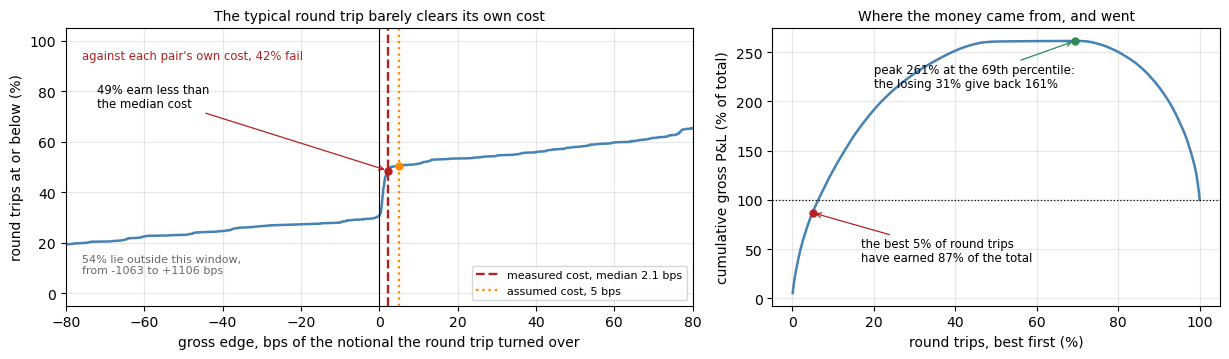

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12.4, 3.7), gridspec_kw={"width_ratios": [1.4, 1]})

# An empirical CDF rather than a histogram: the tails run to ±1,100 bps and the bulk sits in a
# few bins around zero, so a histogram of this either clips the tails into spikes or flattens the
# middle into nothing. The CDF shows both, and reads off the one number that matters here --
# where the cost line crosses it is the share of round trips that never covered their own cost.
a = ax[0]
xs = np.sort(e.to_numpy())
ys = np.arange(1, n + 1) / n * 100
a.plot(xs, ys, lw=1.8, color="steelblue")
a.set_xlim(-80, 80)
a.axvline(0, color="k", lw=0.8)
for x, col, ls, lab in [(c.median(), "firebrick", "--", f"measured cost, median {c.median():.1f} bps"),
                        (COST_BPS, "darkorange", ":", f"assumed cost, {COST_BPS:g} bps")]:
    a.axvline(x, color=col, lw=1.7, ls=ls, label=lab)
    a.plot([x], [(e < x).mean() * 100], "o", ms=5, color=col)
# two readings, and the arrow must point at the one it names: the marker is the share below the
# *median* cost, while the share that fails against each pair's own cost is the real quantity and
# cannot be read off a single vertical line
a.annotate(f"{(e < c.median()).mean() * 100:.0f}% earn less than\nthe median cost",
           xy=(c.median(), (e < c.median()).mean() * 100), xytext=(-72, 74), fontsize=8.4,
           arrowprops=dict(arrowstyle="->", lw=0.9, color="firebrick"))
a.annotate(f"against each pair's own cost, {(net < 0).mean() * 100:.0f}% fail",
           xy=(-76, 93), fontsize=8.4, color="firebrick")
a.annotate(f"{(e.abs() > 80).mean() * 100:.0f}% lie outside this window,\n"
           f"from {e.min():.0f} to {e.max():+.0f} bps", xy=(-76, 8), fontsize=8, color="dimgrey")
a.set_xlabel("gross edge, bps of the notional the round trip turned over")
a.set_ylabel("round trips at or below (%)")
a.set_title("The typical round trip barely clears its own cost", fontsize=10)
a.legend(fontsize=8, loc="lower right")

a = ax[1]
srt = np.sort(LED["pnl_gross"].to_numpy())[::-1]
cum = np.cumsum(srt) / srt.sum() * 100
pct = np.arange(1, n + 1) / n * 100
a.plot(pct, cum, lw=1.8, color="steelblue")
a.axhline(100, color="k", lw=0.9, ls=":")
top5 = cum[int(0.05 * n) - 1]
a.plot([5], [top5], "o", ms=5, color="firebrick")
a.annotate(f"the best 5% of round trips\nhave earned {top5:.0f}% of the total",
           xy=(5, top5), xytext=(17, 38), fontsize=8.4,
           arrowprops=dict(arrowstyle="->", lw=0.9, color="firebrick"))
k = int(np.argmax(cum))
a.plot([pct[k]], [cum[k]], "o", ms=5, color="seagreen")
a.annotate(f"peak {cum[k]:.0f}% at the {pct[k]:.0f}th percentile:\n"
           f"the losing {100 - pct[k]:.0f}% give back {cum[k] - 100:.0f}%",
           xy=(pct[k], cum[k]), xytext=(20, 215), fontsize=8.4,
           arrowprops=dict(arrowstyle="->", lw=0.9, color="seagreen"))
a.set_xlabel("round trips, best first (%)"); a.set_ylabel("cumulative gross P&L (% of total)")
a.set_title("Where the money came from, and went", fontsize=10)
fig.tight_layout()

### What the five clauses say

**The first clause passes, and passes easily.** The average round trip earns 33.9 bps of the notional it
turns over and costs 2.9 bps to place. Costs consume 8% of the gross profit; the strategy would still be
gross-profitable at twelve times the measured cost. This is worth stating plainly because it contradicts
a reasonable prior — including the one this repository held until the costs were measured. **Execution is
not what is wrong with this strategy.** Re-running notebook 11's engine with per-pair measured costs
instead of the flat 5 bps moves its Sharpe from 0.402 to 0.476, and even at *zero* cost it only reaches
0.537. The distance from "free" to "realistic" is 0.06 of Sharpe, against a standard error of 0.26.

**The remaining four fail, and they fail on the same underlying fact.** The median round trip earns 2.9
bps gross against a 2.1 bps cost — the *typical* trade barely covers its own commission. The mean is
33.9 because a handful of trades were enormous: 5% of the round trips carry 87% of the gross P&L. A
strategy whose average is carried by 36 observations out of 723 does not have 723 pieces of evidence for
itself, and once the trades are clustered on the 30 formations that actually varied independently, the
$t$ falls from 3.8 to 2.1. Against the $t$ of 5.5 that a single rule selected from 1.74 million screened
would need, 2.1 is not close. And on the formations from 2023 — the only data in this repository that
was never used to choose anything — the net edge is 3.7 bps with a $t$ of 0.16.

**The arithmetic of clause (a) is worth keeping.** Per round trip the net edge is 31 bps against a
standard deviation of 219, an information ratio of 0.14 per bet. The Fundamental Law then says the
annual information ratio is that times the square root of the bets per year: $0.14\times\sqrt{38}=0.87$,
which is roughly what the book delivers. Read the other way, it is a specification: at this edge quality,
an IR of 1.0 needs 49 independent bets a year and an IR of 2.0 needs 198. The book places 38. **The
binding constraint is breadth, not cost and not signal quality** — which is the same conclusion §6
reached from the Fundamental Law, arrived at from the opposite direction.

**Why this is a useful definition even though the answer is no.** It converts "is there an edge" from a
matter of judgement into five arithmetic questions, and it localises the failure. A strategy that failed
clause (0) would need cheaper execution or a coarser horizon. This one fails (a) through (c), which
cannot be fixed by trading better — only by finding more, and more nearly independent, opportunities.
That is a different research programme from the one notebooks 01–17 have been running, and knowing
which one you are on is most of the value of measuring at all.

## 10. So what is alpha, here?

**The short answer to the terminological question.** "Alpha" names four things (§1) and the ambiguity
is not sloppiness — it is that the four are genuinely linked, so a practitioner moving between them
rarely needs to say which one they mean. Two of the four are defined: Jensen's intercept, given a
factor set, and Grinold's conditional expected residual return, given a risk model and an IC. Two are
not: "alpha signal" is a hypothesis with no units, and "the alpha" is money.

**What this repository is doing** is alpha-signal research in exactly sense §1.3, aimed at §1.2. The
$z$-score of a cointegrated spread is a function of past prices, proposed as a forecast of that
spread's residual return. The hedge ratio is the risk model (§2). Everything in notebooks 01–17 is
either the search for such a function, the measurement of how much it forecasts, or the accounting of
what is left after costs. That is the whole discipline.

**What the measurements say, in order.**

1. The book's market beta is 0.052 and its Jensen alpha is 1.59% a year — most of its raw return, and
   **not significant** ($t=1.39$) after twenty years. The long-only foil earns five times as much with
   a higher Sharpe and has *negative* alpha. Return is not alpha; this is what the distinction buys
   you (§3).
2. Alpha moved more when the *sample* changed (1.586 → 1.385) than when three factors were added
   (→ 1.314). And the one factor with a real loading — the leveraged-ETF basket at 0.106, $t=3.98$ —
   is invisible outside the 649 sessions where it is properly measured. There is no model-free alpha,
   and a mismeasured factor leaves you with an alpha that is not clean (§4).
3. The signal's headline IC (0.197 per fold, $t=14$) is reproduced almost exactly by **random,
   uncointegrated pairs** (0.205). Only the pooled IC separates them, and that is the one with the
   dishonest error bar. An IC is not a property of a signal (§5).
4. The Fundamental Law predicts an IR of 1.14–3.38; the book delivers 0.40. Every reason for the gap —
   correlated bets, forecast-blind sizing, an inflated IC, costs outside the formula — is a real defect
   of the design (§6).
5. The signal did not decay, but this book cannot tell you whether alpha decays, because **2022 alone
   is 52% of twenty years of P&L** and nine formations produced no pairs at all. Notebook 12 has a
   clean decay on the same lake; this one has one good year (§7).
6. Against a matched placebo, the same evidence puts the strategy at the **97th** percentile of the
   null by median per-fold Sharpe and the **2nd** by mean. Cointegration screening widens the outcome
   distribution rather than shifting it — and it is selected out of 1.74 million tests, of which 86,950
   would pass uncorrected (§8).
7. Measured rather than assumed, execution costs **2.9 bps** a transaction, not 5, and consume 8% of
   the gross profit. The average round trip earns 33.9 bps of the notional it turns over, so the first
   clause of a tradeable edge passes by a factor of twelve. The other four fail: 87% of the P&L comes
   from 5% of the trades, the $t$ falls to 2.1 once trades are clustered on formations, and on the
   2023–2025 hold-out the net edge is 3.7 bps with $t=0.16$. **Costs are not what is wrong with this
   strategy; breadth is** (§9).

**So, is there alpha here?** Under the market model, on allocated sessions, with the pooled estimator:
1.59% a year, $t=1.39$ — positive, unconfirmed, and smaller than the round-trip cost of the trades that
produce it for much of its range. Under a mean-per-fold estimator against a random-pair null: no. The
two answers are both correct, which is the point the word "alpha" conceals every time it is used
without its qualifiers.

**Alpha and edge are not the same claim.** Everything above §9 asks whether the signal forecasts.
Section 9 asks whether acting on it would have made money worth keeping, and gives that question a
definition with five arithmetic clauses rather than a judgement. The two answers differ: the forecast
is real enough to survive some of the tests in §5, and the edge fails four of the five in §9.

**The practical rule.** A claim of alpha is incomplete unless it names four things: the **factor model**
it is residual to, the **sample** it was measured on, the **estimator** used to aggregate, and the
**null** it was compared against. Every number in this notebook changed materially when one of those
four was varied, and not one trade was changed to do it.

**Caveats.** One asset class, one lake, one strategy family. The factors are ETF proxies built from
lake prices, not Fama–French or a commercial risk model, and the size proxy in particular is nearly
collinear with the market. The placebo matches liquidity and survivorship but not the *number* of
candidates searched, so it is a null for "does this pair trade work", not for "was this pair worth
finding". Inference is not uniform across the notebook and the differences matter:
§§3–4 use Newey–West standard errors at a fixed 21-session lag (§3 shows the conclusions are not
sensitive to the lag), §5's IC standard errors are ordinary ones taken across pair-folds — which is the
right unit but assumes folds are independent, and concurrent folds are not — and §§7–8 use Welch
$t$-tests and a bootstrap with no serial-correlation adjustment at all. Nothing here is held out, because nothing here is
selected: every number is a measurement on results that notebooks 09–12 had already produced.